In [1]:
!pip install --upgrade -q accelerate bitsandbytes transformers==4.48.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 911.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 54.1 MB/s eta 0:00:00


In [2]:
!python --version


Python 3.11.11


In [3]:
import os
import math
import time
import requests
import json
import torch
import random
import cv2
import nltk

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.nn import functional as F

In [4]:
image_path = "/kaggle/input/coco-train-sample-5000/samples/images/"
image_files = os.listdir(image_path)
print(len(image_files), image_files[0])

5000 COCO_train2014_000000351298.jpg


In [5]:
def get_one_image(idx=-1,
                  image_path="/kaggle/input/coco-train-sample-5000/samples/images/"):
    image_files = sorted(os.listdir(image_path))
    data_size = len(image_files)
    assert(idx >=- 1 and idx < data_size)
    if idx < 0:
        idx = random.randint(1, data_size)-1
    print(f"choose index {idx} from total {data_size} images")
    img_path = image_path + image_files[idx]
    img_id = int(image_files[idx].split("_")[-1][:-4])
    image = Image.open(img_path)
    np_image = np.asarray(image)
    return np_image, str(img_id)

def get_captions(caption_file="/kaggle/input/coco-train-sample-5000/samples/captions.json"):
    with open(caption_file, 'r') as f:
        captions = json.load(f)
    return captions

def get_img_captions(img_id, captions):
    return captions[img_id]

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
from transformers import AutoProcessor, LlavaForConditionalGeneration
from transformers import BitsAndBytesConfig

2025-06-13 18:47:11.178785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749840431.388530      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749840431.447457      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [8]:
def load_llava(model_name_or_path,
               device_map="auto",
               quantization = True):

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=quantization,
        bnb_4bit_compute_dtype=torch.float16
    )
    
    processor = AutoProcessor.from_pretrained(model_name_or_path)
    tokenizer = processor.tokenizer
    model = LlavaForConditionalGeneration.from_pretrained(model_name_or_path,
                                                          device_map=device_map,
                                                          quantization_config=quantization_config)
    return model, tokenizer, processor


def get_llava_image_features(model, processor, image):
    inputs = processor(images=image, text="", return_tensors="pt").to(model.device, torch.float16)
    image_features = model.get_image_features(
        pixel_values=inputs.pixel_values,
        vision_feature_layer=model.config.vision_feature_layer,
        vision_feature_select_strategy=model.config.vision_feature_select_strategy
    )
    return image_features


def get_llava_logits(image_feature = None,
                     model=None,
                     tokenizer = None,
                     image_token = None):
        
    batch, _, _ = image_feature.shape
    prompt_strings = [image_token]*batch
    text_inputs = tokenizer(prompt_strings, return_tensors="pt")
    input_ids = text_inputs["input_ids"]
        
    inputs_embeds = model.get_input_embeddings()(input_ids)
    inputs_embeds, attention_mask, labels, position_ids = model._merge_input_ids_with_image_features(image_feature, 
                                                                            inputs_embeds, 
                                                                            input_ids, 
                                                                            text_inputs.attention_mask, 
                                                                            labels=None)

    outputs = model.language_model(
        attention_mask=attention_mask,
        position_ids=position_ids,
        inputs_embeds=inputs_embeds,
    )
    logits = outputs[0]
    return logits

In [9]:
model, tokenizer, processor = load_llava(model_name_or_path="llava-hf/llava-1.5-7b-hf",
                                            device_map="auto",
                                            quantization = True)

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [10]:
print(model)

LlavaForConditionalGeneration(
  (vision_tower): CLIPVisionModel(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
        (position_embedding): Embedding(577, 1024)
      )
      (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-23): 24 x CLIPEncoderLayer(
            (self_attn): CLIPSdpaAttention(
              (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            )
            (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (a

In [11]:
# img_feature_llm = get_llava_image_features(model, processor, img_np)
# print(img_feature_llm.shape)

In [12]:
def get_image_embeddings(model, processor, image):
    inputs = processor(images=image, text="", return_tensors="pt").to(model.device, torch.float16)
    
    image_outputs = model.vision_tower(
        inputs.pixel_values, 
        output_hidden_states=True,
        output_attentions=True,
    )
    
    # print(len(image_outputs.hidden_states))
    # selected_image_feature = image_outputs.hidden_states[model.config.vision_feature_layer]
    # if model.config.vision_feature_select_strategy == "default":
    #     selected_image_feature = selected_image_feature[:, 1:]
    # elif model.config.vision_feature_select_strategy == "full":
    #     selected_image_feature = selected_image_feature
    # else:
    #     raise ValueError(f"Unexpected select feature strategy: {self.config.vision_feature_select_strategy}")
    # # print(selected_image_feature.shape)
    # image_features = model.multi_modal_projector(selected_image_feature)
    
    return image_outputs


def get_cls_attention(img_embedding):
    select_layer = model.config.vision_feature_layer
    selected_attention = img_embedding['attentions'][select_layer][0,:,0,:]
    return torch.mean(selected_attention, 0)[1:]

def get_avg_attention(img_embedding):
    select_layer = model.config.vision_feature_layer
    selected_attention = img_embedding['attentions'][select_layer][0,:,1:,1:]
    return torch.mean(torch.mean(selected_attention, 0),0)


def show_saliency_map(img_np, saliency_map):
    height, width, _ = img_np.shape
    r_height = height // 24 * 24
    r_width = width // 24 * 24

    pil_image = Image.fromarray(img_np)
    resized_img = pil_image.resize((r_width, r_height), Image.BICUBIC)
    image = np.asarray(resized_img)
    
    h, w, _ = image.shape
    saliency_map = saliency_map.detach().cpu().reshape((24, 24)).numpy()
    saliency_map = np.repeat(saliency_map, h // 24 , axis=0)
    saliency_map = np.repeat(saliency_map, w // 24, axis=1)

    fig, ax = plt.subplots(1)
    ax.imshow(img_np)
    plt.imshow(saliency_map, cmap='jet', alpha=0.5)  # 0.4 = transparency level
    ax.set_axis_off()


def show_topk_patches(img_np, saliency_map, topk=20):
    height, width, _ = img_np.shape
    r_height = height // 24 * 24
    r_width = width // 24 * 24

    pil_image = Image.fromarray(img_np)
    resized_img = pil_image.resize((r_width, r_height), Image.BICUBIC)
    image = np.asarray(resized_img)
    img = np.float32(image) / 255
    
    h, w, _ = image.shape
    topk_map = saliency_map.detach().cpu().reshape((24, 24)).numpy()
    threshold = np.sort(saliency_map.detach().cpu().numpy())[-topk]
    
    selected_patches = np.zeros((24,24))
    selected_patches[topk_map>=threshold] = 1
    # print(selected_patches)

    mask = np.repeat(selected_patches, h // 24 , axis=0)
    mask = np.repeat(mask, w // 24, axis=1)

    binary_mask = (mask > 0.5).astype(np.uint8)
    color_map = np.zeros((binary_mask.shape[0], binary_mask.shape[1], 3), dtype=np.uint8)
    color_map[binary_mask == 0] = [0, 0, 255]
    color_map[binary_mask == 1] = [0, 255, 0]

    heatmap = np.float32(color_map) / 255

    mixed_img = img * 0.5 + heatmap * 0.5

    fig, ax = plt.subplots(1)
    ax.imshow(mixed_img)
    ax.set_axis_off()

choose index 2070 from total 5000 images


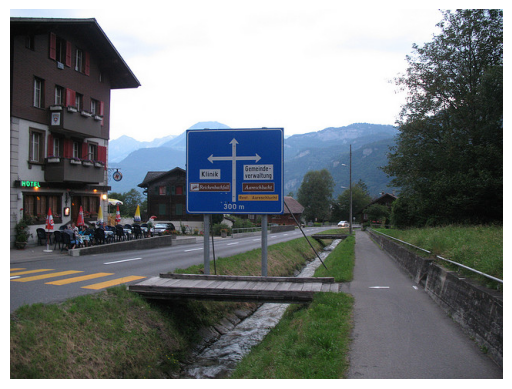

In [13]:
img_np, img_id = get_one_image(idx=-1)
height, width, _ = img_np.shape

fig, ax = plt.subplots(1)
ax.imshow(img_np)
ax.set_axis_off()

In [14]:
print(model.config.output_attentions)
print(model.config.output_hidden_states)
print(model.config.vision_feature_layer)
print(model.config.vision_feature_select_strategy)


img_embedding = get_image_embeddings(model, processor, img_np)
print(img_embedding.keys())
print(img_embedding['last_hidden_state'].shape) # 1, 577, 1024
print(img_embedding['pooler_output'].shape) # 1, 1024
print(len(img_embedding['hidden_states']), img_embedding['hidden_states'][0].shape) # 25, 1, 577, 1024
print(len(img_embedding['attentions']), img_embedding['attentions'][0].shape) # 1, 16, 577, 577


False
False
-2
default


CLIPModel is using CLIPSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


odict_keys(['last_hidden_state', 'pooler_output', 'hidden_states', 'attentions'])
torch.Size([1, 577, 1024])
torch.Size([1, 1024])
25 torch.Size([1, 577, 1024])
24 torch.Size([1, 16, 577, 577])


In [15]:
cls_atten = get_cls_attention(img_embedding)
avg_atten = get_avg_attention(img_embedding)

# print(cls_atten.shape, torch.sum(cls_atten))
# print(avg_atten.shape, torch.sum(avg_atten))

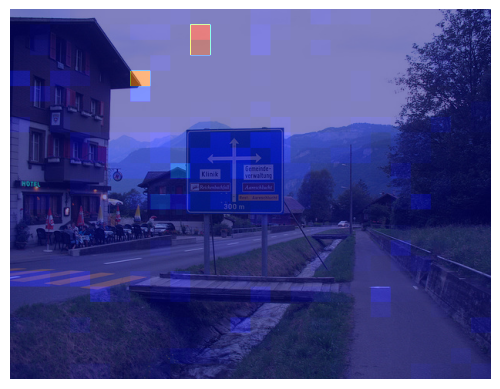

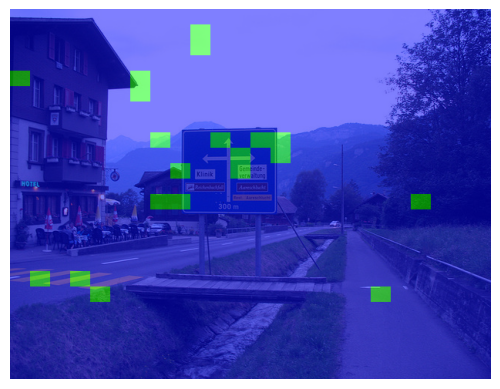

In [16]:
show_saliency_map(img_np, cls_atten)
show_topk_patches(img_np, cls_atten, topk=20)

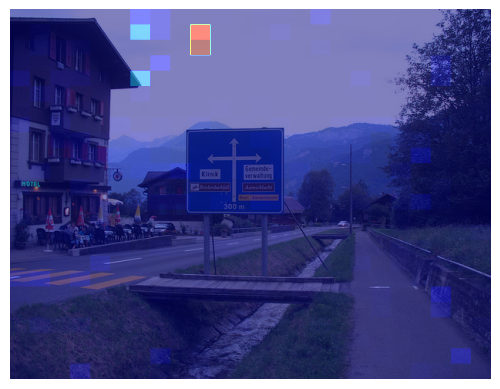

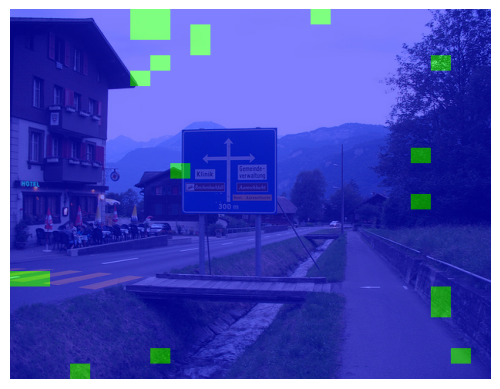

In [17]:
show_saliency_map(img_np, avg_atten)
show_topk_patches(img_np, avg_atten, topk=20)

In [18]:
# topk_map = cls_atten.detach().cpu().numpy()
threshold = np.sort(cls_atten.detach().cpu().numpy())[-50]
lst = cls_atten.detach().cpu().tolist()
print(lst>=threshold)

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False  True False False
 False False False False False False False False False False False False
 False False False False False False False False False  True False False
  True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
  True False  True False False False  True False False False False False
 False False False False False False False False False False False False
 False  True False False False False  True False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False Fa

In [19]:
# prompt1 = "USER: <image>\n describe the image ASSISTANT:"
# prompt2 = "<image>\n describe the image. "
# prompt3 = "USER: <image> Is this artwork created by zuccarelli, francesco? Please answer yes or no. ASSISTANT:"


# inputs = processor(images=img_np, text=prompt3, return_tensors='pt').to(model.device, torch.float16)
# output = model.generate(**inputs)
# generated_sequences = processor.batch_decode(output,skip_special_tokens=True,
#                                              clean_up_tokenization_spaces=False)
# print(generated_sequences)

In [20]:
def generate_objects(model, processor, img_np):
    # prompt = "USER: <image>\nPlease list distinct, singular object names in the image. Do not include colors, materials, or adjectives. Only name the actual objects, separated by commas.\nASSISTANT:"
    prompt = (
        "USER: <image>\n"
        "Please list all distinct, singular object names clearly visible in the image. "
        "Include people or animals if present. Do not include colors, materials, or adjectives. "
        "Only name the actual objects, separated by commas.\nASSISTANT:"
    )
    inputs = processor(images=img_np, text=prompt, return_tensors='pt').to(model.device, torch.float16)
    input_len = inputs["input_ids"].shape[1]
    with torch.inference_mode():
        output = model.generate(**inputs, max_new_tokens=32)
    generated_ids = output[:,input_len:]
    generated_sequences = processor.batch_decode(generated_ids,
                                                 skip_special_tokens=True,
                                                 clean_up_tokenization_spaces=False)

    obj_set = set([obj.strip().lower() for obj in generated_sequences[0].split(",")])
    
    return list(obj_set)
    


choose index 694 from total 5000 images
['people', 'bench', 'water', 'dog', 'car', 'boat', 'trees', 'house', 'truck', 'person', 'fence post', 'tele', 'fence', 'grass'] 2.942140579223633


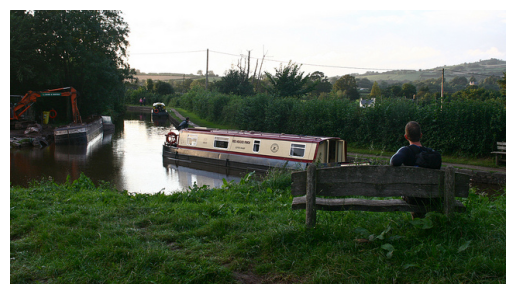

In [21]:
img_np, img_id = get_one_image(idx=-1)
height, width, _ = img_np.shape

fig, ax = plt.subplots(1)
ax.imshow(img_np)
ax.set_axis_off()

start_time = time.time()
obj_list = generate_objects(model, processor, img_np)
end_time = time.time()
print(obj_list, end_time-start_time)

In [22]:
img_np, img_id = get_one_image(idx=-1)
height, width, _ = img_np.shape

# fig, ax = plt.subplots(1)
# ax.imshow(img_np)
# ax.set_axis_off()

start_time = time.time()
obj_list = generate_objects(model, processor, img_np)
end_time = time.time()
print(obj_list, end_time-start_time)

def batch_iterative_elimination(model, obj_list, inputs, 
                                threshold=0.5, 
                                failure_patch_num=50, 
                                img_token_id=32000, 
                                image_token_size=576):
    logits_generate_config = {
        "return_dict_in_generate": True,
        "output_hidden_states": True,
        "max_new_tokens": 1,
    }
    first_img_token_idx = (inputs["input_ids"][0]==img_token_id).nonzero(as_tuple=True)[0][0].detach().cpu().numpy()
    projection_layer = model.language_model.lm_head

    obj_token_ids = list(set([ids for obj in obj_list for ids in tokenizer(obj)["input_ids"][1:]]))
    patch_list = list(range(image_token_size))
    num_patch = 0
    prob_list = []
    
    failure_patch_list = patch_list
    failure_prob_list = []

    for i in range(10):
        t1 = time.time()
        num_patch = len(patch_list)
        mask_list = [first_img_token_idx+idx for idx in patch_list]
        inputs["attention_mask"][0,first_img_token_idx:first_img_token_idx+image_token_size] = 0
        inputs["attention_mask"][0,mask_list] = 1
        input_kwargs = {**inputs, **logits_generate_config}
        t2 = time.time()
        
        with torch.inference_mode():
            outputs = model.generate(**input_kwargs)
            hidden_states = torch.stack(outputs.hidden_states[0])[:,:,first_img_token_idx:first_img_token_idx+image_token_size,:]
            logits = projection_layer(hidden_states).cpu()
            prob = F.softmax(logits, dim=-1).detach().cpu().numpy()
            internal_conf_heatmap = np.max(prob[:,:,:, obj_token_ids], axis=-1).squeeze()
        probs = np.max(internal_conf_heatmap, axis=0)

        t3 = time.time()
        if not prob_list:
            prob_list = probs
            failure_prob_list = probs
            
        probs_mask = np.zeros_like(probs)
        probs_mask[patch_list] = probs[patch_list] 

        filter_patch_length = sum(probs_mask > threshold)
        
        indices = np.argsort(probs_mask)[::-1]
        patch_list = indices[:filter_patch_length].tolist()
        prob_list = probs[patch_list].tolist()

        print(f"Iteration: {i}, Remaining patches: {filter_patch_length}")

        if filter_patch_length >= failure_patch_num:
            failure_patch_list = patch_list
            failure_prob_list = prob_list
        t4 = time.time()

        # print(f"Input propressing: {(t2-t1):.4f}")
        # print(f"Logit length: {(t3-t2):.4f}")
        # print(f"Elimination: {(t4-t3):.4f}")
        
        if len(patch_list) == 0:
            print(False, len(failure_patch_list))
            return failure_patch_list, failure_prob_list, False

        if len(patch_list) == num_patch:
            break

    print(True, len(patch_list))
    return patch_list, prob_list, True


prompt = "USER: <image>\n Describe the image. \nASSISTANT:"
inputs = processor(images=img_np, 
                   text=prompt, 
                   return_tensors="pt").to(model.device)

start_time = time.time()
patch_list, prob_list, converged = batch_iterative_elimination(
    model, obj_list, inputs, 
    threshold=0.5, failure_patch_num=50)
# end_time = time.time()
# print(patch_list)
# print(end_time-start_time)


choose index 3866 from total 5000 images
['child', 'elephant', 'stick', 'man'] 1.1474425792694092


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


Iteration: 0, Remaining patches: 38
Iteration: 1, Remaining patches: 22
Iteration: 2, Remaining patches: 21
Iteration: 3, Remaining patches: 21
True 21


In [23]:
# generation_config = {
#     "temperature": 1.0,
#     "num_beams": 5,
#     "use_cache": True,
#     "max_new_tokens": 16,
# }

# inputs = processor(images=img_np, 
#                    text=prompt, 
#                    return_tensors="pt").to(model.device, torch.float16)

# mask_list = [5+idx for idx in patch_list]
# inputs["attention_mask"][0,5:5+576] = 0
# inputs["attention_mask"][0,mask_list] = 1
# input_kwargs = {**inputs, **generation_config}

# with torch.inference_mode():
#     outputs = model.generate(**input_kwargs)

# generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
# print(generated_ids)

# print(tokenizer.decode(generated_ids, skip_special_tokens=True))

In [24]:
def percentage_iterative_elimination(model, obj_list, inputs, 
                                     rate=0.5, iters=4,
                                     img_token_id=32000, 
                                     image_token_size=576):
    logits_generate_config = {
        "return_dict_in_generate": True,
        "output_hidden_states": True,
        "max_new_tokens": 1,
    }
    first_img_token_idx = (inputs["input_ids"][0]==img_token_id).nonzero(as_tuple=True)[0][0].detach().cpu().numpy()
    projection_layer = model.language_model.lm_head

    remain_patches_num = image_token_size
    obj_token_ids = list(set([ids for obj in obj_list for ids in tokenizer(obj)["input_ids"][1:]]))
    patch_list = list(range(image_token_size))
    prob_list = []
    
    for i in range(iters):
        t1 = time.time()
        remain_patches_num = int(remain_patches_num * rate)
        
        mask_list = [first_img_token_idx+idx for idx in patch_list]
        inputs["attention_mask"][0,first_img_token_idx:first_img_token_idx+image_token_size] = 0
        inputs["attention_mask"][0,mask_list] = 1
        input_kwargs = {**inputs, **logits_generate_config}

        t2 = time.time()
        with torch.inference_mode():
            outputs = model.generate(**input_kwargs)
            hidden_states = torch.stack(outputs.hidden_states[0])[:,:,first_img_token_idx:first_img_token_idx+image_token_size,:]
            logits = projection_layer(hidden_states).cpu()
            prob = F.softmax(logits, dim=-1).detach().cpu().numpy()
            internal_conf_heatmap = np.max(prob[:,:,:, obj_token_ids], axis=-1).squeeze()
        probs = np.max(internal_conf_heatmap, axis=0)
        
        t3 = time.time()
        
        probs_mask = np.zeros_like(probs)
        probs_mask[patch_list] = probs[patch_list] 
        
        indices = np.argsort(probs_mask)[::-1]
        patch_list = indices[:remain_patches_num].tolist()
        prob_list = probs[patch_list].tolist()

        t4 = time.time()

        print(f"Input propressing: {(t2-t1):.4f}")
        print(f"Logit length: {(t3-t2):.4f}")
        print(f"Elimination: {(t4-t3):.4f}")

        print(len(patch_list))
        print(patch_list)

    return patch_list, prob_list


prompt = "USER: <image>\n Describe the image. \nASSISTANT:"
inputs = processor(images=img_np, 
                   text=prompt, 
                   return_tensors="pt").to(model.device)


start_time = time.time()
patch_list, prob_list = percentage_iterative_elimination(model, obj_list, inputs, rate=0.5, iters=4)
end_time = time.time()
print(patch_list)

# print(end_time-start_time)

# print(patch_list)
# print(prob_list)

Input propressing: 0.0009
Logit length: 2.8556
Elimination: 0.0002
288
[224, 198, 226, 301, 225, 185, 250, 533, 199, 263, 252, 344, 313, 551, 539, 300, 490, 395, 385, 170, 536, 257, 234, 573, 205, 311, 336, 348, 307, 305, 366, 150, 265, 217, 149, 276, 235, 197, 216, 380, 256, 405, 220, 294, 552, 527, 332, 171, 574, 368, 247, 174, 186, 277, 318, 343, 159, 400, 287, 330, 246, 429, 359, 378, 269, 558, 403, 270, 213, 379, 308, 503, 212, 187, 404, 160, 258, 188, 236, 273, 192, 356, 327, 526, 575, 442, 477, 427, 218, 428, 282, 169, 453, 184, 329, 180, 280, 126, 355, 275, 156, 354, 351, 283, 293, 328, 271, 452, 340, 292, 384, 509, 161, 106, 297, 572, 353, 345, 304, 414, 119, 96, 375, 557, 321, 530, 56, 151, 230, 528, 506, 255, 231, 566, 422, 478, 82, 360, 367, 418, 520, 326, 35, 206, 278, 339, 398, 183, 279, 208, 36, 173, 210, 504, 37, 435, 33, 264, 91, 302, 465, 466, 181, 325, 58, 441, 492, 515, 260, 434, 303, 390, 467, 561, 323, 416, 480, 152, 306, 26, 331, 158, 365, 175, 460, 410, 80, 232,

In [25]:
def percentage_iterative_elimination(model, obj_list, img_np, 
                                     rate=0.5, iters=4,
                                     img_token_id=32000, 
                                     image_token_size=576):
    prompt = "USER: <image>\n Describe the image. \nASSISTANT:"
    inputs = processor(images=img_np, 
                       text=prompt, 
                       return_tensors="pt").to(model.device, torch.float16)

    image_features = model.get_image_features(
        pixel_values=inputs.pixel_values,
        vision_feature_layer=model.config.vision_feature_layer,
        vision_feature_select_strategy=model.config.vision_feature_select_strategy
    )
    inputs.pop("pixel_values")
    
    logits_generate_config = {
        "return_dict_in_generate": True,
        "output_hidden_states": True,
        "max_new_tokens": 1,
    }
    # first_img_token_idx = (inputs["input_ids"] == img_token_id).nonzero()[0][1].detach().cpu().numpy()
    projection_layer = model.language_model.lm_head

    remain_patches_num = image_token_size
    obj_token_ids = list(set([ids for obj in obj_list for ids in tokenizer(obj)["input_ids"][1:]]))
    patch_list = list(range(image_token_size))
    prob_list = []
    
    for i in range(iters):
        remain_patches_num = int(remain_patches_num * rate)

        reduced_image_feature = image_features[:, patch_list, :]
        img_token_start_idx = (inputs["input_ids"] == img_token_id).nonzero()[0][1].detach().cpu().numpy()
        img_token_end_idx = img_token_start_idx + image_token_size
        input_ids = torch.cat(
            (inputs["input_ids"][:, :img_token_start_idx+len(patch_list)],
             inputs["input_ids"][:, img_token_end_idx+1:]), dim=1)
        attention_mask = inputs["attention_mask"][:, :input_ids.shape[-1]]
        inputs_embeds = model.get_input_embeddings()(input_ids)
        inputs_embeds[:, img_token_start_idx:img_token_start_idx + len(patch_list), :] = reduced_image_feature
        
        inputs["input_ids"] = input_ids
        inputs["attention_mask"] = attention_mask
        inputs["inputs_embeds"] = inputs_embeds
        
        input_kwargs = {**inputs, **logits_generate_config}

        with torch.inference_mode():
            outputs = model.generate(**input_kwargs)
            hidden_states = torch.stack(outputs.hidden_states[0])[:,:,img_token_start_idx:img_token_start_idx+len(patch_list),:]
            logits = projection_layer(hidden_states).cpu()
            prob = F.softmax(logits, dim=-1).detach().cpu().numpy()
            internal_conf_heatmap = np.max(prob[:,:,:, obj_token_ids], axis=-1).squeeze()
        
        probs = np.max(internal_conf_heatmap, axis=0)
        print(probs.shape)
        # probs_mask = np.zeros_like(probs)
        # probs_mask[patch_list] = probs[patch_list] 
        
        # indices = np.argsort(probs_mask)[::-1]
        # patch_list = indices[:remain_patches_num].tolist()
        # prob_list = probs[patch_list].tolist()

    return patch_list, prob_list


start_time = time.time()
patch_list, prob_list = percentage_iterative_elimination(
    model, obj_list, img_np, rate=0.5, iters=1)
end_time = time.time()
print(patch_list)


(576,)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 22

In [26]:
# img_np, img_id = get_one_image(idx=-1)
# height, width, _ = img_np.shape

# start_time = time.time()
# obj_list = generate_objects(model, processor, img_np)
# end_time = time.time()
# print(obj_list, end_time-start_time)

# generation_config = {
#     "temperature": 0.0,
#     "use_cache": True,
#     "max_new_tokens": 8,
# }
# prompt = f"USER: <image> \n Describe the image.\n ASSISTANT:"

# start_time = time.time()
# patch_list, prob_list, converged = batch_iterative_elimination(model, obj_list, inputs, 
#                                                                threshold=0.4, failure_patch_num=30)
# end_time = time.time()
# print(f"PE time: {(end_time-start_time):.4f}")


# start_time = time.time()
# patch_list, prob_list = percentage_iterative_elimination(model, obj_list, inputs, rate=0.5, iters=4)
# end_time = time.time()
# print(f"PPE time: {(end_time-start_time):.4f}")

# start_time = time.time()
# with torch.no_grad():
#     inputs = processor(images=img_np, 
#                        text=prompt, 
#                        return_tensors="pt").to(model.device)
#     input_len = inputs["input_ids"].shape[1]
#     input_kwargs = {**inputs, **generation_config}
#     output = model.generate(**input_kwargs)
#     generated_ids = output[0][input_len:]

# response = tokenizer.decode(generated_ids, skip_special_tokens=True)
# end_time = time.time()
# print(f"Baseline time: {(end_time-start_time):.4f}")
